# تجميع صور الأسطح باستخدام HOG و K-Means

هذه نسخة مبسطة من الدفتر. الهدف أن تكون الخطوات واضحة لطالب جامعي: نقرأ الصور، نحول كل صورة إلى أرقام بسيطة باستخدام HOG، ثم نستخدم K-Means لتقسيم الصور إلى مجموعتين.

## 1. استيراد المكتبات

In [578]:
import os
import shutil
from collections import Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

## 2. الإعدادات الأساسية

In [791]:
DATASET_PATH = "dataset"
OUTPUT_PATH = "output_clusters"

CLASSES = ["roofless", "withroof"]
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

IMAGE_SIZE = (128, 128)
N_CLUSTERS = 2
RANDOM_STATE = 42

# إعدادات HOG: كلما كبرت الخلية قل تأثير التفاصيل الصغيرة والضجيج.
HOG_ORIENTATIONS = 3 #0,20,40,60,80,100,120,140,160
HOG_PIXELS_PER_CELL = (32,32) #cell pixcels
HOG_CELLS_PER_BLOCK = (2, 2) #each block multiple cells

## 3. قراءة الصور من المجلدات

In [794]:
def load_images():
    images = []
    image_paths = []
    true_labels = []

    for label in CLASSES:
        folder = os.path.join(DATASET_PATH, label)

        if not os.path.isdir(folder):
            print("لم يتم العثور على المجلد:", folder)
            continue

        for file_name in sorted(os.listdir(folder)):
            if not file_name.lower().endswith(IMAGE_EXTENSIONS):
                continue

            path = os.path.join(folder, file_name)
            image = cv2.imread(path)

            if image is None:
                print("تعذر قراءة الصورة:", path)
                continue

            image = cv2.resize(image, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
            images.append(image)
            image_paths.append(path)
            true_labels.append(label)

    return images, image_paths, true_labels


images, image_paths, true_labels = load_images()
len(true_labels)
print(image_paths[0]+" , "+true_labels[0])



تعذر قراءة الصورة: dataset\withroof\1.png
dataset\roofless\1 (1).png , roofless


In [795]:
Counter(true_labels)

Counter({'roofless': 79, 'withroof': 61})

In [797]:
print("عدد الصور:", len(images))
print("توزيع الصور:", dict(Counter(true_labels)))

if len(images) == 0:
    raise ValueError("لم يتم العثور على أي صور داخل مجلد dataset.")

if len(images) < N_CLUSTERS:
    raise ValueError("عدد الصور يجب أن يكون أكبر أو يساوي عدد العناقيد.")

عدد الصور: 140
توزيع الصور: {'roofless': 79, 'withroof': 61}


## 4. استخراج ميزات HOG

ميزة HOG تلخص اتجاهات الحواف داخل الصورة. بدل أن نعطي الخوارزمية الصورة كاملة، نعطيها أرقامًا تمثل شكل الحواف.

In [801]:
features = []
for image in images:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    image_features = hog(
        gray,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm="L2-Hys",
        transform_sqrt=True,
        feature_vector=True
    )

    features.append(image_features)

features = np.array(features)
features_scaled = StandardScaler().fit_transform(features)

print("شكل مصفوفة الميزات:", features_scaled.shape)

شكل مصفوفة الميزات: (140, 108)


In [802]:
features[0]

array([0.32014644, 0.32014644, 0.2307052 , 0.32014644, 0.32014644,
       0.32014644, 0.23063756, 0.32014644, 0.32014644, 0.25858034,
       0.08226604, 0.32014644, 0.33280596, 0.33280596, 0.33280596,
       0.30227341, 0.33280596, 0.18268381, 0.24054705, 0.07652884,
       0.33280596, 0.19031341, 0.33280596, 0.33280596, 0.31105895,
       0.33591606, 0.18799349, 0.33591606, 0.15314076, 0.33591606,
       0.19584484, 0.33591606, 0.33591606, 0.33591606, 0.12734324,
       0.33591606, 0.21554952, 0.32410522, 0.32410522, 0.24166432,
       0.07688429, 0.32410522, 0.22107016, 0.32410522, 0.32410522,
       0.32410522, 0.32410522, 0.32410522, 0.22858182, 0.07272216,
       0.31962193, 0.18084688, 0.31962193, 0.31962193, 0.31962193,
       0.31962193, 0.31962193, 0.30412302, 0.31962193, 0.31962193,
       0.19447548, 0.33498698, 0.33498698, 0.33498698, 0.12645285,
       0.33498698, 0.3270417 , 0.33498698, 0.33498698, 0.17949592,
       0.14662867, 0.33498698, 0.2128604 , 0.29757922, 0.29757

## 5. تطبيق K-Means

In [804]:
kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=20
)

cluster_labels = kmeans.fit_predict(features_scaled)
print("أرقام العناقيد لأول 10 صور:", cluster_labels[:10])

number_of_groups = len(set(cluster_labels))
if 1 < number_of_groups < len(images):
    score = silhouette_score(features_scaled, cluster_labels)
    print("Silhouette Score:", round(score, 3))

أرقام العناقيد لأول 10 صور: [1 1 0 1 1 1 1 1 1 1]
Silhouette Score: 0.201


In [807]:
cluster_labels

array([1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0])

## 6. حفظ الصور حسب العنقود

In [811]:
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

for path, cluster_id in zip(image_paths, cluster_labels):
    cluster_folder = os.path.join(OUTPUT_PATH, f"cluster_{cluster_id}")
    os.makedirs(cluster_folder, exist_ok=True)

    file_name = os.path.basename(path)
    new_path = os.path.join(cluster_folder, file_name)
    shutil.copy(path, new_path)
print("تم حفظ النتائج داخل:", OUTPUT_PATH)

تم حفظ النتائج داخل: output_clusters


## 7. تحليل نتيجة التجميع

سنقارن كل عنقود مع أسماء المجلدات الأصلية لمعرفة الفئة الغالبة داخله.

In [818]:
cluster_majority = {}
correct_images = 0

print("===== تحليل العناقيد =====")

for cluster_id in sorted(set(cluster_labels)):
    labels_in_cluster = []

    for i, label in enumerate(true_labels):
        if cluster_labels[i] == cluster_id:
            labels_in_cluster.append(label)

    counts = Counter(labels_in_cluster)
    majority_label, majority_count = counts.most_common(1)[0]

    cluster_majority[cluster_id] = majority_label
    correct_images += majority_count

    print("\nCluster", cluster_id)
    print("عدد الصور:", len(labels_in_cluster))
    print("التوزيع:", dict(counts))
    print("الفئة الغالبة:", majority_label)

accuracy = correct_images / len(true_labels)
wrong_images = len(true_labels) - correct_images

print("\nالدقة التقريبية:", f"{accuracy:.2%}")
print("عدد الصور غير المتوافقة مع أغلبية عنقودها:", wrong_images)

===== تحليل العناقيد =====

Cluster 0
عدد الصور: 47
التوزيع: {'roofless': 1, 'withroof': 46}
الفئة الغالبة: withroof

Cluster 1
عدد الصور: 93
التوزيع: {'roofless': 78, 'withroof': 15}
الفئة الغالبة: roofless

الدقة التقريبية: 88.57%
عدد الصور غير المتوافقة مع أغلبية عنقودها: 16


In [816]:
cluster_labels

array([1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0])

In [828]:
true_labels

['roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',

In [832]:
cluster_majority = {}
correct_images = 0

print("===== تحليل العناقيد =====")
cluster_id=1
labels_in_cluster = []

for i, label in enumerate(true_labels):
    if cluster_labels[i] == cluster_id:
        labels_in_cluster.append(label)
labels_in_cluster

===== تحليل العناقيد =====


['roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',
 'roofless',

In [568]:

counts = Counter(labels_in_cluster)
majority_label, majority_count = counts.most_common(1)[0]
majority_count


50

In [572]:
cluster_majority[cluster_id] = majority_label
cluster_majority

{0: 'withroof'}

In [ ]:
correct_images += majority_count

print("\nCluster", cluster_id)
print("عدد الصور:", len(labels_in_cluster))
print("التوزيع:", dict(counts))
print("الفئة الغالبة:", majority_label)

accuracy = correct_images / len(true_labels)
wrong_images = len(true_labels) - correct_images

print("\nالدقة التقريبية:", f"{accuracy:.2%}")
print("عدد الصور غير المتوافقة مع أغلبية عنقودها:", wrong_images)

In [541]:
    print(path,true_label,cluster_id)

dataset\roofless\1 (1).png roofless 1
dataset\roofless\1 (10).png roofless 1
dataset\roofless\1 (100).png roofless 0
dataset\roofless\1 (11).png roofless 1
dataset\roofless\1 (12).png roofless 1
dataset\roofless\1 (13).png roofless 1
dataset\roofless\1 (14).png roofless 1
dataset\roofless\1 (15).png roofless 1
dataset\roofless\1 (16).png roofless 1
dataset\roofless\1 (17).png roofless 1
dataset\roofless\1 (18).png roofless 1
dataset\roofless\1 (19).png roofless 1
dataset\roofless\1 (2).png roofless 1
dataset\roofless\1 (20).png roofless 1
dataset\roofless\1 (21).png roofless 1
dataset\roofless\1 (22).png roofless 1
dataset\roofless\1 (23).png roofless 1
dataset\roofless\1 (24).png roofless 1
dataset\roofless\1 (25).png roofless 1
dataset\roofless\1 (26).png roofless 1
dataset\roofless\1 (27).png roofless 1
dataset\roofless\1 (28).png roofless 1
dataset\roofless\1 (29).png roofless 1
dataset\roofless\1 (3).png roofless 1
dataset\roofless\1 (30).png roofless 1
dataset\roofless\1 (31).png

In [543]:
cluster_majority

{0: 'withroof', 1: 'roofless'}

## 8. استخراج الصور المشبوهة

الصورة المشبوهة هي صورة موجودة في مجلد معين، لكن العنقود الذي دخلت فيه أغلبه من المجلد الآخر.

In [820]:
suspicious = []

for path, true_label, cluster_id in zip(image_paths, true_labels, cluster_labels):
    majority_label = cluster_majority[cluster_id]

    if true_label != majority_label:
        suspicious.append((path, true_label, cluster_id, majority_label))

if len(suspicious) == 0:
    print("لا توجد صور مشبوهة واضحة.")
else:
    suspicious_folder = os.path.join(OUTPUT_PATH, "suspicious_images")
    os.makedirs(suspicious_folder, exist_ok=True)

    print("===== الصور المشبوهة =====")

    for path, true_label, cluster_id, majority_label in suspicious:
        file_name = os.path.basename(path)
        new_name = f"{true_label}__cluster_{cluster_id}__majority_{majority_label}__{file_name}"
        shutil.copy(path, os.path.join(suspicious_folder, new_name))

        print("\nالمسار:", path)
        print("موجودة في مجلد:", true_label)
        print("لكن أغلب العنقود:", majority_label)

    print("\nتم حفظ الصور المشبوهة داخل:", suspicious_folder)

===== الصور المشبوهة =====

المسار: dataset\roofless\1 (100).png
موجودة في مجلد: roofless
لكن أغلب العنقود: withroof

المسار: dataset\withroof\112 (1).png
موجودة في مجلد: withroof
لكن أغلب العنقود: roofless

المسار: dataset\withroof\112 (13).png
موجودة في مجلد: withroof
لكن أغلب العنقود: roofless

المسار: dataset\withroof\112 (2).png
موجودة في مجلد: withroof
لكن أغلب العنقود: roofless

المسار: dataset\withroof\112 (20).png
موجودة في مجلد: withroof
لكن أغلب العنقود: roofless

المسار: dataset\withroof\112 (26).png
موجودة في مجلد: withroof
لكن أغلب العنقود: roofless

المسار: dataset\withroof\112 (38).png
موجودة في مجلد: withroof
لكن أغلب العنقود: roofless

المسار: dataset\withroof\112 (39).png
موجودة في مجلد: withroof
لكن أغلب العنقود: roofless

المسار: dataset\withroof\112 (4).png
موجودة في مجلد: withroof
لكن أغلب العنقود: roofless

المسار: dataset\withroof\112 (41).png
موجودة في مجلد: withroof
لكن أغلب العنقود: roofless

المسار: dataset\withroof\112 (46).png
موجودة في مجلد: withroof
لكن

In [782]:
suspicious

[('dataset\\roofless\\1 (100).png', 'roofless', 2, 'withroof'),
 ('dataset\\roofless\\1 (8).png', 'roofless', 3, 'withroof'),
 ('dataset\\withroof\\112 (11).png', 'withroof', 0, 'roofless'),
 ('dataset\\withroof\\112 (26).png', 'withroof', 1, 'roofless'),
 ('dataset\\withroof\\112 (38).png', 'withroof', 1, 'roofless'),
 ('dataset\\withroof\\112 (39).png', 'withroof', 1, 'roofless'),
 ('dataset\\withroof\\112 (4).png', 'withroof', 0, 'roofless'),
 ('dataset\\withroof\\112 (41).png', 'withroof', 4, 'roofless'),
 ('dataset\\withroof\\112 (46).png', 'withroof', 1, 'roofless'),
 ('dataset\\withroof\\112 (53).png', 'withroof', 1, 'roofless')]

## 9. رسم العناقيد في بعدين باستخدام PCA

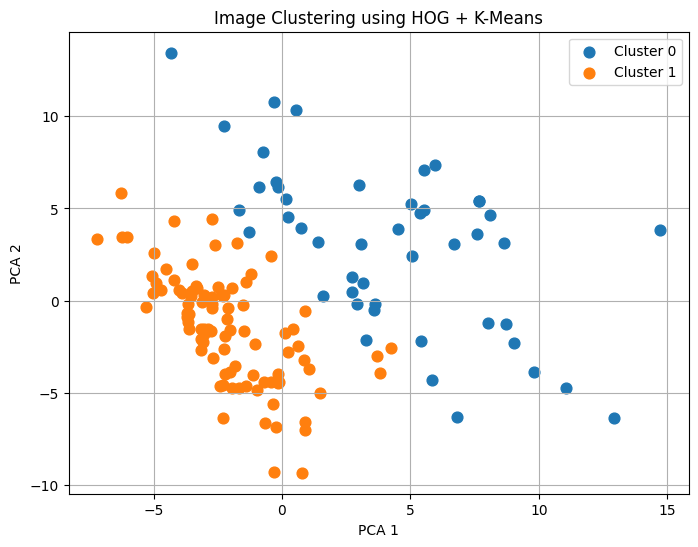

In [822]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
features_2d = pca.fit_transform(features_scaled)

plt.figure(figsize=(8, 6))

for cluster_id in sorted(set(cluster_labels)):
    mask = cluster_labels == cluster_id
    plt.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        s=60,
        label=f"Cluster {cluster_id}"
    )

plt.title("Image Clustering using HOG + K-Means")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.legend()
plt.show()

## 10. عرض أمثلة من كل عنقود

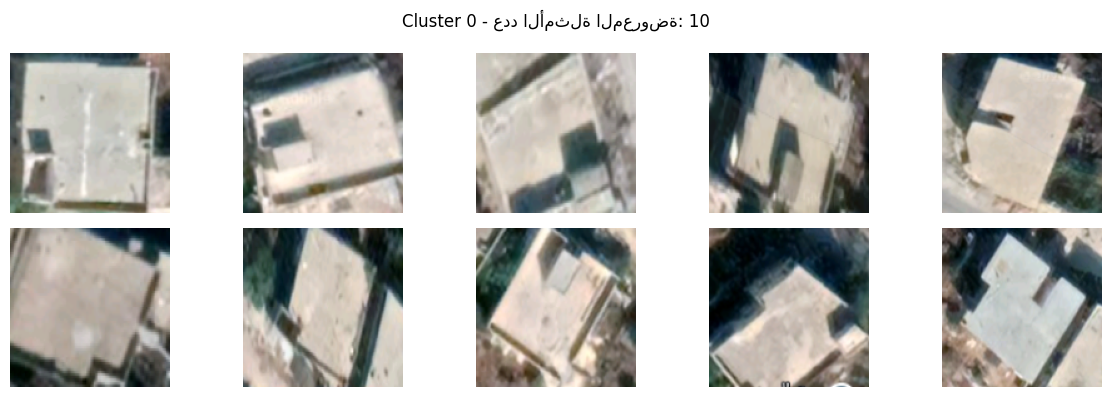

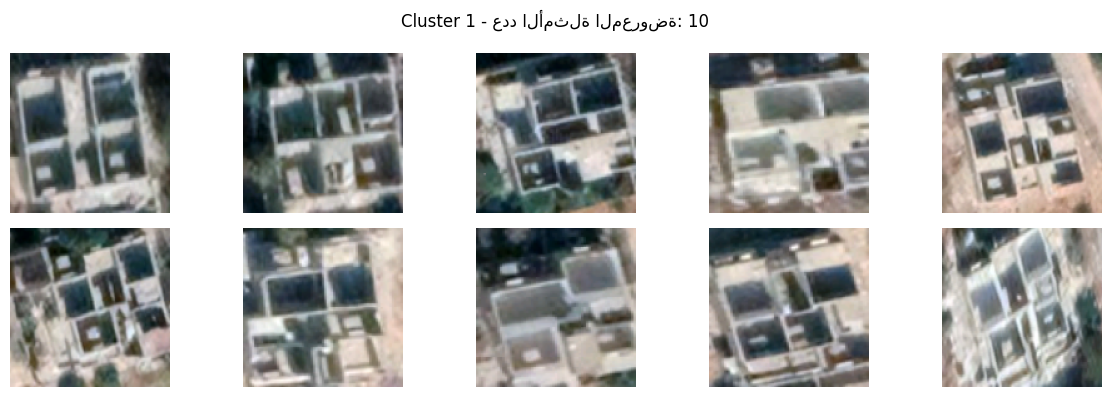

In [824]:
for cluster_id in sorted(set(cluster_labels)):
    indexes = []

    for i, label in enumerate(cluster_labels):
        if label == cluster_id:
            indexes.append(i)

    indexes = indexes[:10]

    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Cluster {cluster_id} - عدد الأمثلة المعروضة: {len(indexes)}")

    for plot_number, image_index in enumerate(indexes, start=1):
        image_rgb = cv2.cvtColor(images[image_index], cv2.COLOR_BGR2RGB)

        plt.subplot(2, 5, plot_number)
        plt.imshow(image_rgb)
        plt.axis("off")
    plt.tight_layout()
    plt.show()